In [109]:
pip install "numpy<2"

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

df = pd.read_csv("spambase_csv_Kaggle.csv")
print("Head \n", df.head())
print("Shape\n", df.shape)

Head 
    word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00            0.00  ...           0.00      

In [111]:
print("Null Values\n", df.isnull().sum())
print("Describe\n", df.describe())

Null Values
 word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet           

In [112]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()

#for col in numeric_cols:
#    df[col] = StandardScaler().fit_transform(df[[col]])

df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [113]:
from sklearn.preprocessing import StandardScaler

X = df.drop("class", axis = 1)
Y = df["class"]
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

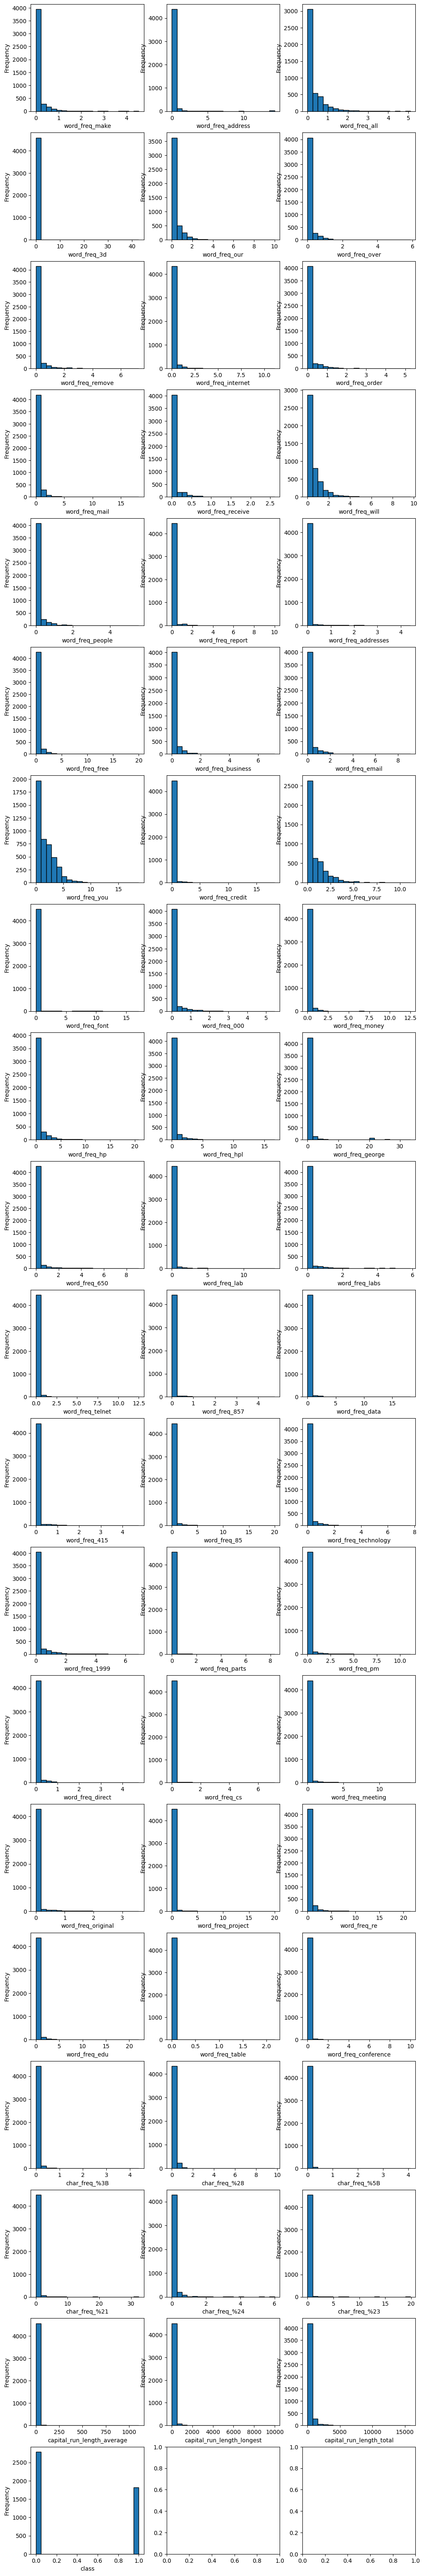

In [114]:
fig, axes = plt.subplots(20,3, figsize=(12, 80))
axes = axes.flatten()

for i in range (len(numeric_cols)):
    axes[i].hist(df[numeric_cols[i]], bins= 20, edgecolor = "black")
    # axes[i].set_title(numeric_cols[i])
    axes[i].set_xlabel(numeric_cols[i])
    axes[i].set_ylabel("Frequency")

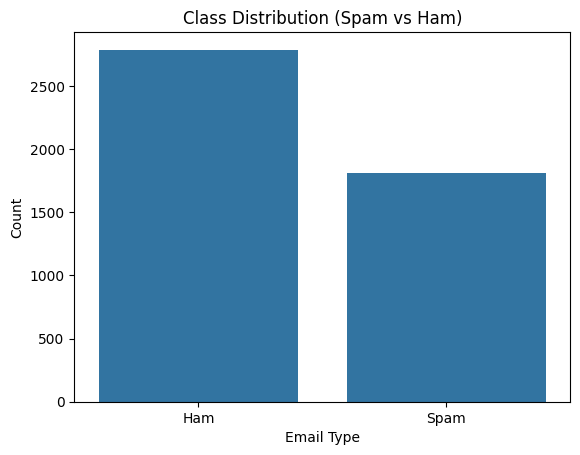

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="class", data=df)
plt.xticks([0, 1], ["Ham", "Spam"])
plt.title("Class Distribution (Spam vs Ham)")
plt.xlabel("Email Type")
plt.ylabel("Count")

plt.savefig("classDistribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

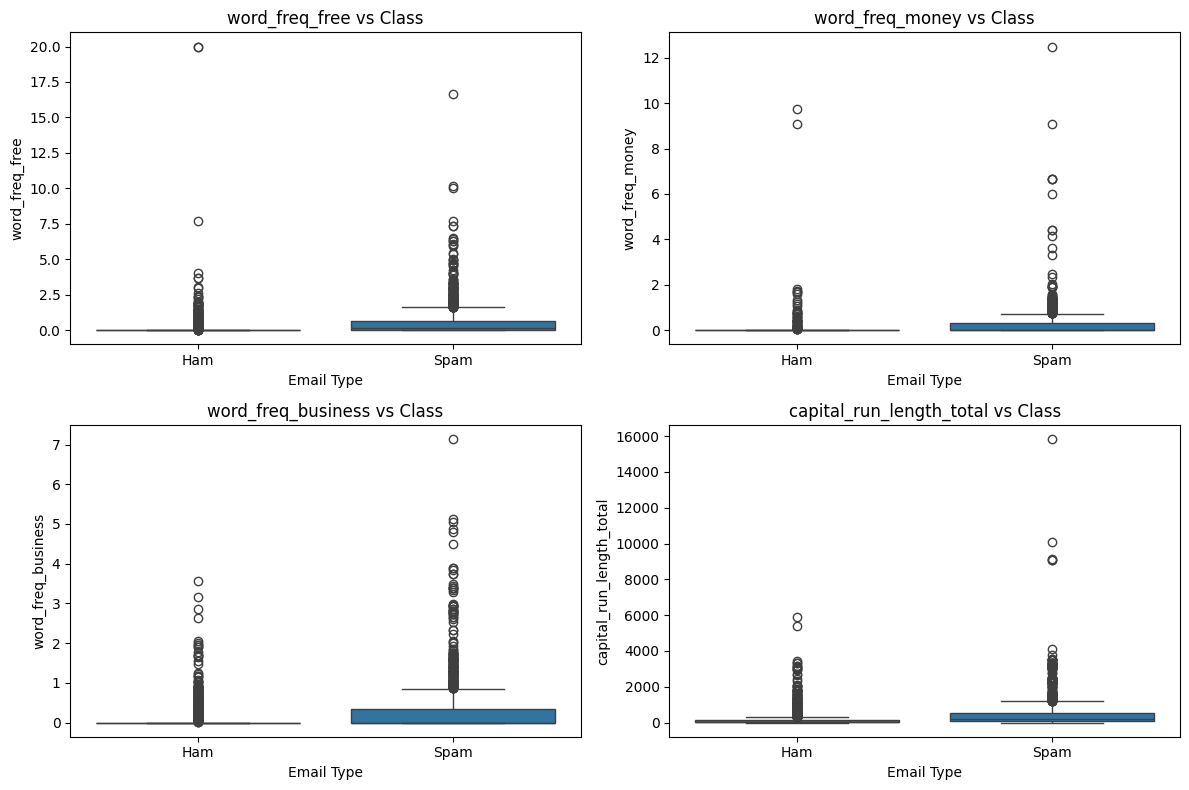

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "word_freq_free",
    "word_freq_money",
    "word_freq_business",
    "capital_run_length_total"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        x="class",
        y=feature,
        data=df,
        order=[0, 1],
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} vs Class")
    axes[i].set_xlabel("Email Type")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Ham", "Spam"])

plt.tight_layout()
plt.savefig("boxPlotsImportantFeatures.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

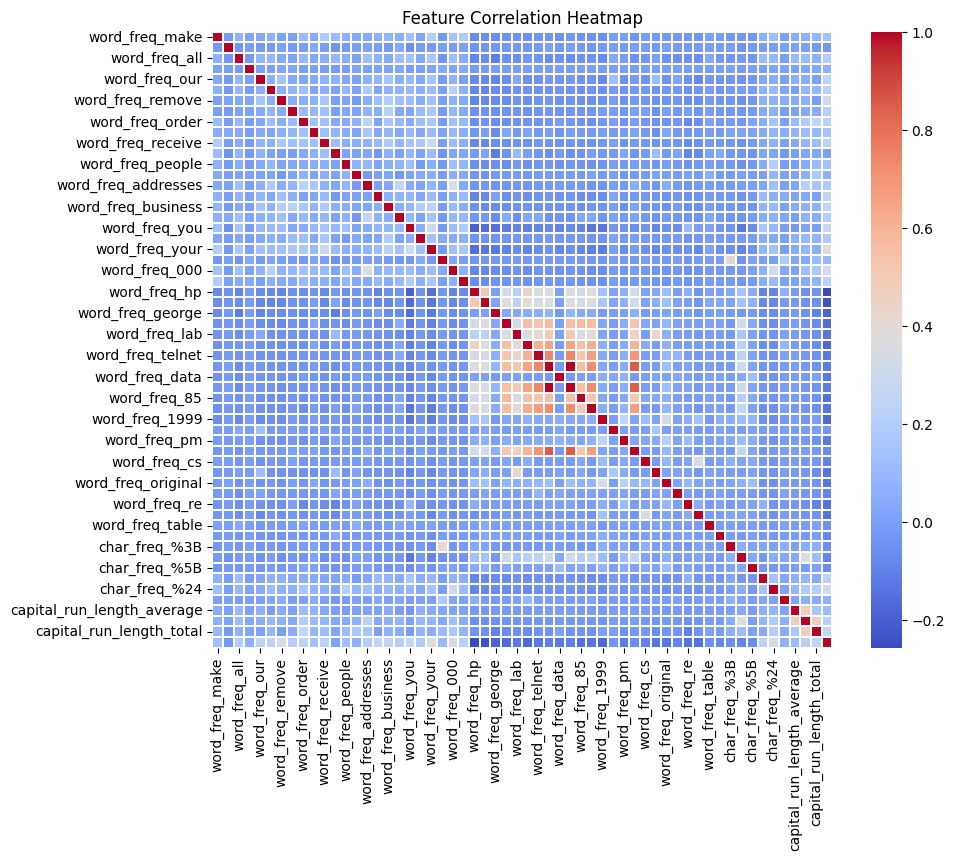

In [117]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.2)
plt.title("Feature Correlation Heatmap")
plt.show()

In [118]:
X = df.drop("class", axis=1)
y = df["class"]

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y   
)

In [120]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()
X_test_raw  = X_test.copy()

In [121]:
print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (3220, 57)
Validation size: (690, 57)
Test size: (691, 57)


In [122]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [123]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

y_val_pred_gnb = gnb.predict(X_val_scaled)
print("GaussianNB Validation Accuracy:",
      accuracy_score(y_val, y_val_pred_gnb))

GaussianNB Validation Accuracy: 0.8173913043478261


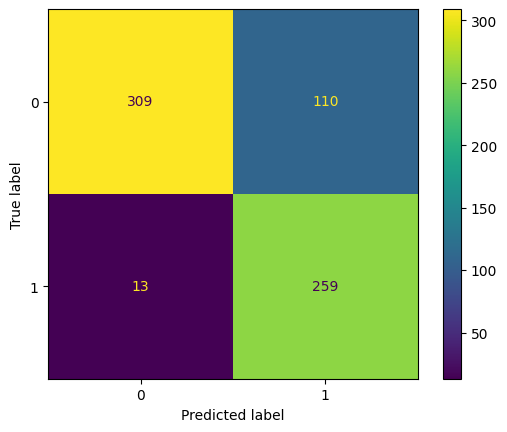

In [124]:
y_pred = gnb.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.savefig("confusionGNB.png",
            dpi=300,
            bbox_inches="tight")

In [125]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB(alpha=1.0)  # Laplace smoothing
mnb.fit(X_train_raw, y_train)

y_val_pred_mnb = mnb.predict(X_val_raw)
print("MultinomialNB Validation Accuracy:",
      accuracy_score(y_val, y_val_pred_mnb))

MultinomialNB Validation Accuracy: 0.7753623188405797


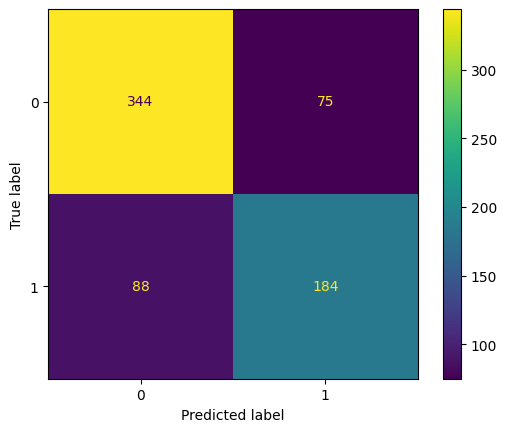

In [126]:
y_pred = mnb.predict(X_test_raw)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.savefig("confusionMNB.png",
            dpi=300,
            bbox_inches="tight")

In [127]:
from sklearn.naive_bayes import BernoulliNB

X_train_bin = (X_train > 0).astype(int)
X_val_bin   = (X_val > 0).astype(int)

bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train)

y_val_pred_bnb = bnb.predict(X_val_bin)
print("BernoulliNB Validation Accuracy:",
      accuracy_score(y_val, y_val_pred_bnb))

BernoulliNB Validation Accuracy: 0.9188405797101449


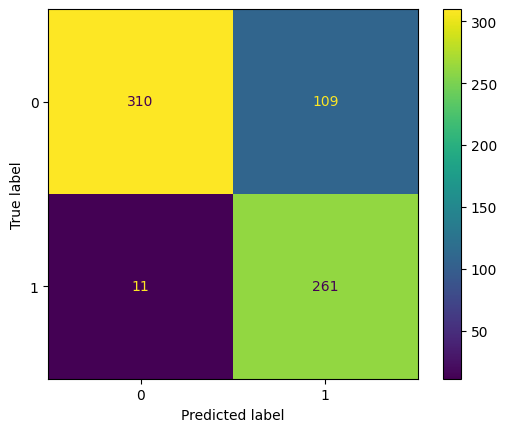

In [128]:
y_pred = bnb.predict(X_test_bin)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.savefig("confusionBNB.png",
            dpi=300,
            bbox_inches="tight")

In [129]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)
y_val_pred_knn = knn.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred_knn)
print("Validation Accuracy (KNN):", val_accuracy)


Validation Accuracy (KNN): 0.9057971014492754


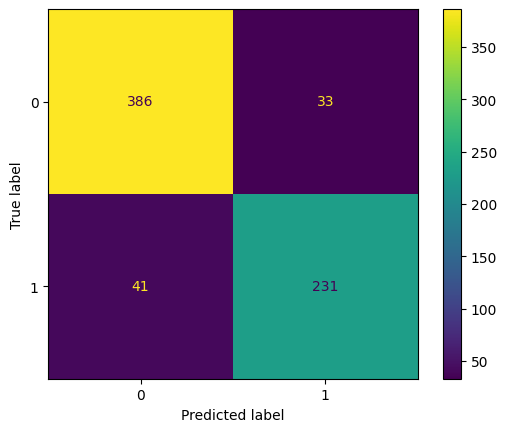

In [130]:
y_pred = knn.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.savefig("confusionKNNBase.png",
            dpi=300,
            bbox_inches="tight")

In [131]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"]
}

In [132]:
knn_base = KNeighborsClassifier()

grid = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

grid.fit(X_train, y_train)

best_knn_grid = grid.best_estimator_

In [133]:
best_knn = grid.best_estimator_

y_test_pred = best_knn.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Test Accuracy: 0.9175108538350217


In [134]:
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'n_neighbors': 9, 'weights': 'distance'}
Best CV Accuracy: 0.9183229813664596


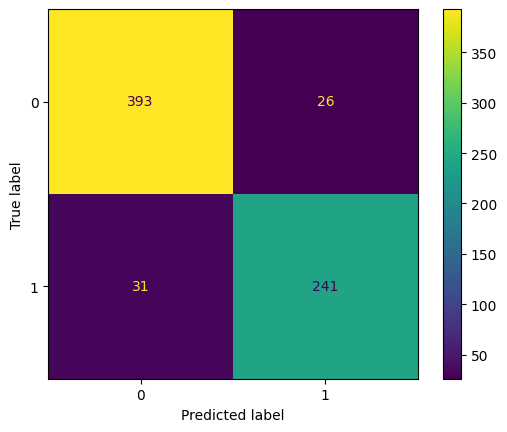

In [135]:
y_pred = best_knn_grid.fit(X_train, y_train).predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.savefig("confusionKNNGrid.png",
            dpi=300,
            bbox_inches="tight")

In [136]:
from sklearn.neighbors import KNeighborsClassifier

param_dist = {
    "n_neighbors": range(1, 31),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

In [137]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV

knn_base = KNeighborsClassifier()

random_search = RandomizedSearchCV(
    estimator=knn_base,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

best_knn_random = random_search.best_estimator_

print("Random Search Best Params:", random_search.best_params_)
print("Random Search Best CV Accuracy:", random_search.best_score_)

Random Search Best Params: {'weights': 'distance', 'n_neighbors': 10, 'metric': 'euclidean'}
Random Search Best CV Accuracy: 0.9170807453416149


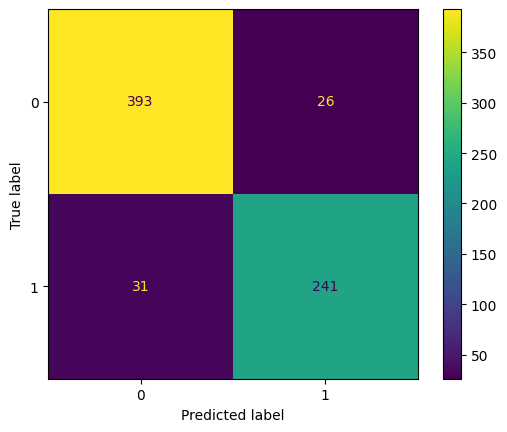

In [138]:
y_pred = best_knn_random.fit(X_train, y_train).predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [139]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_kdtree = KNeighborsClassifier(
    n_neighbors=grid.best_params_["n_neighbors"],
    weights=grid.best_params_["weights"],
    algorithm="kd_tree",
    metric="euclidean"
)

knn_kdtree.fit(X_train, y_train)

,n_neighbors,9
,weights,'distance'
,algorithm,'kd_tree'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [140]:
y_val_pred_kd = knn_kdtree.predict(X_val)
print("Validation Accuracy (KDTree KNN):",
      accuracy_score(y_val, y_val_pred_kd))

Validation Accuracy (KDTree KNN): 0.9159420289855073


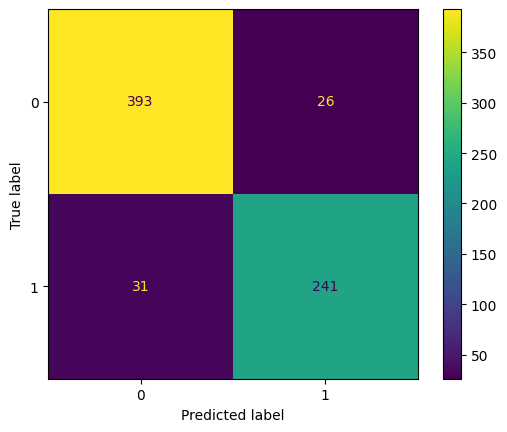

In [141]:
y_pred = knn_kdtree.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.savefig("confusionKDTree.png",
            dpi=300,
            bbox_inches="tight")

In [142]:
knn_balltree = KNeighborsClassifier(
    n_neighbors=grid.best_params_["n_neighbors"],
    weights=grid.best_params_["weights"],
    algorithm="ball_tree",
    metric="euclidean"
)

knn_balltree.fit(X_train, y_train)

,n_neighbors,9
,weights,'distance'
,algorithm,'ball_tree'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [143]:
y_val_pred_ball = knn_balltree.predict(X_val)
print("Validation Accuracy (BallTree KNN):",
      accuracy_score(y_val, y_val_pred_ball))

Validation Accuracy (BallTree KNN): 0.9159420289855073


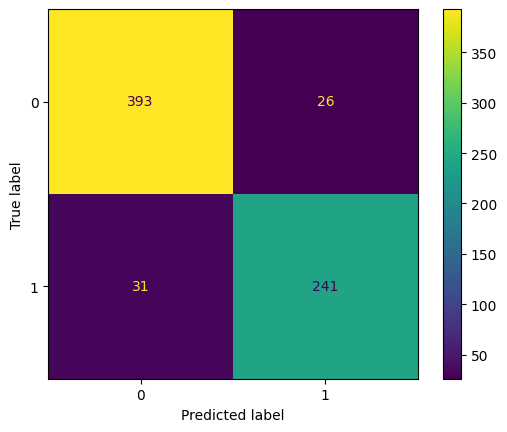

In [144]:
y_pred = knn_balltree.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.savefig("confusionKNNBallTree.png",
            dpi=300,
            bbox_inches="tight")

In [145]:
from sklearn.neighbors import KNeighborsClassifier

knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [146]:
knn_baseline.fit(X_train, y_train)
#knn_kdtree.fit(X_train, y_train)
#knn_balltree.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


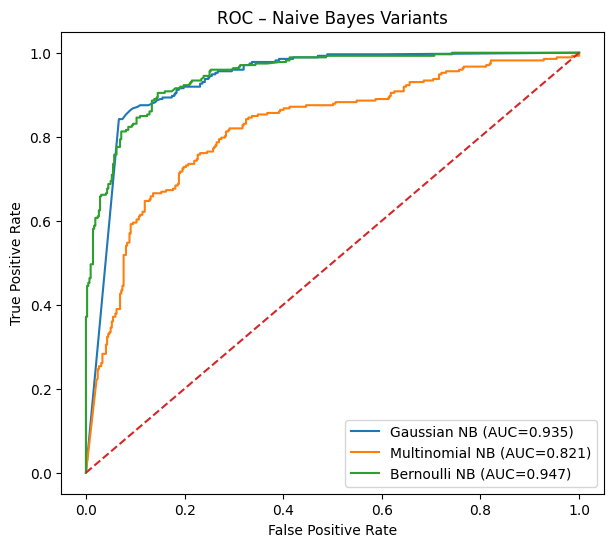

In [147]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

# Gaussian NB
y_prob_gnb = gnb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_gnb)
plt.plot(fpr, tpr, label=f"Gaussian NB (AUC={auc(fpr,tpr):.3f})")

# Multinomial NB
y_prob_mnb = mnb.predict_proba(X_test_raw)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_mnb)
plt.plot(fpr, tpr, label=f"Multinomial NB (AUC={auc(fpr,tpr):.3f})")

# Bernoulli NB
X_test_bin = (X_test_raw > 0).astype(int)
y_prob_bnb = bnb.predict_proba(X_test_bin)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_bnb)
plt.plot(fpr, tpr, label=f"Bernoulli NB (AUC={auc(fpr,tpr):.3f})")

plt.plot([0, 1], [0, 1], "--")
plt.title("ROC – Naive Bayes Variants")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("ROCNB.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

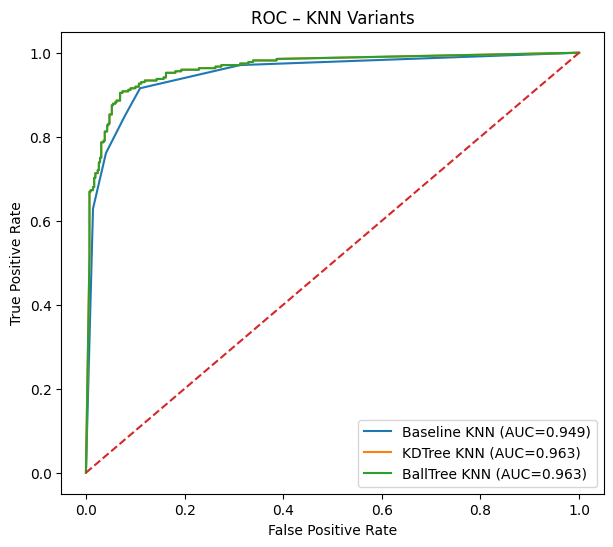

In [148]:
plt.figure(figsize=(7, 6))

# Baseline KNN
y_prob_knn = knn_baseline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
plt.plot(fpr, tpr, label=f"Baseline KNN (AUC={auc(fpr,tpr):.3f})")

# KDTree KNN
y_prob_kd = knn_kdtree.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_kd)
plt.plot(fpr, tpr, label=f"KDTree KNN (AUC={auc(fpr,tpr):.3f})")

# BallTree KNN
y_prob_ball = knn_balltree.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_ball)
plt.plot(fpr, tpr, label=f"BallTree KNN (AUC={auc(fpr,tpr):.3f})")

plt.plot([0, 1], [0, 1], "--")
plt.title("ROC – KNN Variants")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("ROCKNN.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [149]:
k_values = (1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27)

train_acc = []
val_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    val_pred = knn.predict(X_val)

    train_acc.append(accuracy_score(y_train, train_pred))
    val_acc.append(accuracy_score(y_val, val_pred))

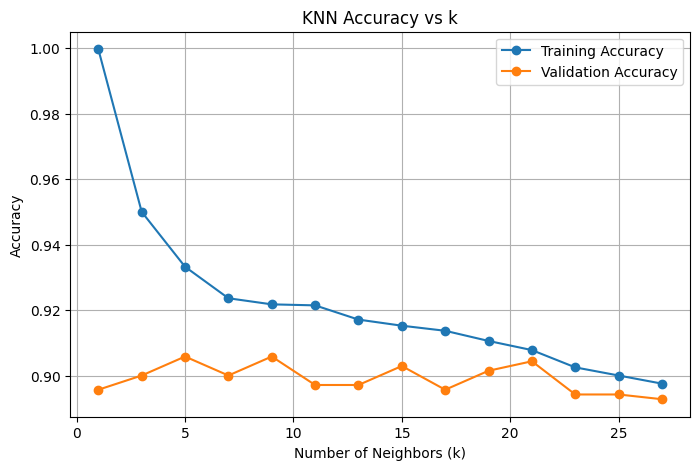

In [150]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_acc, marker="o", label="Training Accuracy")
plt.plot(k_values, val_acc, marker="o", label="Validation Accuracy")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k")
plt.legend()
plt.grid(True)

plt.savefig("KNNAccuracyVsK.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [151]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    
    # ---- Training Time ----
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # ---- Prediction Time ----
    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred

    # ---- Confusion Matrix ----
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # ---- Metrics ----
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    specificity = tn / (tn + fp)
    fpr = fp / (fp + tn)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Specificity": specificity,
        "False Positive Rate": fpr,
        "Train Time (s)": train_time,
        "Predict Time (s)": pred_time,
    }

In [152]:
from sklearn.naive_bayes import GaussianNB

results = []

results.append(evaluate_model(GaussianNB(), X_train, y_train, X_test, y_test,"GaussianNB"))
results.append(evaluate_model(knn_baseline, X_train, y_train, X_test, y_test, "Baseline KNN"))
results.append(evaluate_model(best_knn_grid, X_train, y_train, X_test, y_test, "Grid Tuned KNN"))
results.append(evaluate_model(best_knn_random, X_train, y_train, X_test, y_test, "Random Tuned KNN"))
results.append(evaluate_model(knn_kdtree, X_train, y_train, X_test, y_test, "KDTree KNN"))
results.append(evaluate_model(knn_balltree, X_train, y_train, X_test, y_test, "BallTree KNN"))
results.append(evaluate_model(BernoulliNB(),X_train_bin, y_train, X_test_bin, y_test, "BernoulliNB"))
results.append(evaluate_model(MultinomialNB(alpha=1.0),X_train_raw, y_train, X_test_raw, y_test, "MultinomialNB"))


In [153]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,False Positive Rate,Train Time (s),Predict Time (s)
0,GaussianNB,0.821997,0.701897,0.952206,0.808112,0.737470,0.262530,0.008973,0.004003
1,Baseline KNN,0.892909,0.875000,0.849265,0.861940,0.921241,0.078759,0.004964,0.065000
2,Grid Tuned KNN,0.917511,0.902622,0.886029,0.894249,0.937947,0.062053,0.004960,0.013001
3,Random Tuned KNN,0.917511,0.902622,0.886029,0.894249,0.937947,0.062053,0.009001,0.016998
4,KDTree KNN,0.917511,0.902622,0.886029,0.894249,0.937947,0.062053,0.050003,0.177046
5,BallTree KNN,0.917511,0.902622,0.886029,0.894249,0.937947,0.062053,0.019003,0.224969
6,BernoulliNB,0.826339,0.705405,0.959559,0.813084,0.739857,0.260143,0.012997,0.002999
7,MultinomialNB,0.764110,0.710425,0.676471,0.693032,0.821002,0.178998,0.005968,0.003005


In [154]:
def check_fit_status(model, X_train, y_train, X_val, y_val, model_name):

    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    return {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Validation Accuracy": accuracy_score(y_val, y_val_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Validation F1": f1_score(y_val, y_val_pred),
    }

In [155]:
fit_results = []

fit_results.append(
    check_fit_status(GaussianNB(),X_train, y_train, X_val, y_val,"GaussianNB"))

fit_results.append(
    check_fit_status(MultinomialNB(alpha=1.0),X_train_raw, y_train,X_val_raw, y_val,"MultinomialNB"))

fit_results.append(
    check_fit_status(BernoulliNB(),X_train_bin, y_train,X_val_bin, y_val,"BernoulliNB"))

fit_results.append(
    check_fit_status(knn_baseline,X_train, y_train,X_val, y_val,"Baseline KNN"))

fit_results.append(
    check_fit_status(best_knn_grid,X_train, y_train,X_val, y_val,"Grid Tuned KNN"))

fit_results.append(
    check_fit_status(best_knn_random,X_train, y_train,X_val, y_val,"Random Tuned KNN"))

fit_results.append(
    check_fit_status(knn_kdtree,X_train, y_train,X_val, y_val,"KDTree KNN"))

fit_results.append(
    check_fit_status(knn_balltree, X_train, y_train, X_val, y_val,"BallTree KNN"))

In [156]:
fit_df = pd.DataFrame(fit_results)
fit_df

,Model,Train Accuracy,Validation Accuracy,Train F1,Validation F1
0,GaussianNB,0.817081,0.817391,0.805289,0.803125
1,MultinomialNB,0.786335,0.775362,0.722804,0.706994
2,BernoulliNB,0.902484,0.918841,0.870888,0.892720
3,Baseline KNN,0.933230,0.905797,0.914513,0.879852
4,Grid Tuned KNN,0.999689,0.915942,0.999606,0.894161
5,Random Tuned KNN,0.999689,0.920290,0.999606,0.899452
6,KDTree KNN,0.999689,0.915942,0.999606,0.894161
7,BallTree KNN,0.999689,0.915942,0.999606,0.894161


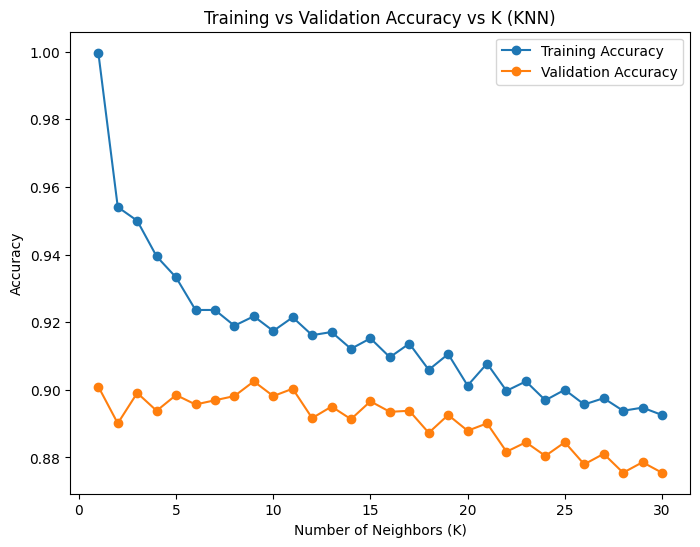

In [157]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

k_values = range(1, 31)

train_acc = []
val_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Training accuracy
    train_acc.append(knn.score(X_train, y_train))

    # Cross-validated validation accuracy
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring="accuracy")
    val_acc.append(scores.mean())

plt.figure(figsize=(8,6))
plt.plot(k_values, train_acc, marker="o", label="Training Accuracy")
plt.plot(k_values, val_acc, marker="o", label="Validation Accuracy")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy vs K (KNN)")
plt.legend()
plt.show()

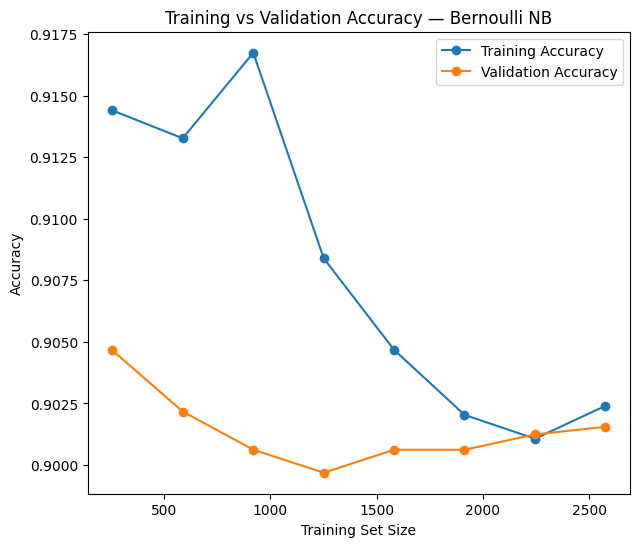

In [158]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=bnb,   # Bernoulli NB
    X=X_train,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

plt.figure(figsize=(7,6))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training Accuracy")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation Accuracy")

plt.title("Training vs Validation Accuracy — Bernoulli NB")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()